# Customer Churn Prediction using Machine Learning

This notebook explores the Telco Customer Churn dataset and performs **Exploratory Data Analysis (EDA)** to understand customer behavior and identify patterns related to churn.

## Project Objective

The goal of this project is to **predict whether a customer will churn** (leave the telecom service) based on their demographic profile, account information, and service usage.

By analyzing historical customer data, we aim to:
- Understand the factors that influence customer churn
- Identify patterns in the data through visualization and statistical summaries
- Build a foundation for developing a machine learning model that can help the business retain at-risk customers

## Import Libraries

We begin by importing the essential Python libraries for data manipulation, numerical computation, and visualization.

In [43]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent visual style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Dataset

The dataset contains information about telecom customers, including their services, billing details, and whether they churned. We load it from the `data` folder relative to the project root.

In [44]:
# Load the Telco Customer Churn dataset
data_path = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully! Shape: {df.shape}")

Dataset loaded successfully! Shape: (7043, 21)


## Dataset Overview

Before building any model, we inspect the dataset to understand its structure, data types, and potential data quality issues.

### First 5 Rows

A quick look at the first few records helps us understand what each column represents.

In [45]:
# Display the first 5 rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Shape

The shape tells us how many customers (rows) and features (columns) are in the dataset.

In [46]:
# Number of rows and columns
print(f"Number of rows (customers): {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")

Number of rows (customers): 7043
Number of columns (features): 21


### Column Names

Listing all column names gives us a complete picture of the available features.

In [47]:
# Display all column names
print("Column names:")
for i, col in enumerate(df.columns, start=1):
    print(f"  {i:2d}. {col}")

Column names:
   1. customerID
   2. gender
   3. SeniorCitizen
   4. Partner
   5. Dependents
   6. tenure
   7. PhoneService
   8. MultipleLines
   9. InternetService
  10. OnlineSecurity
  11. OnlineBackup
  12. DeviceProtection
  13. TechSupport
  14. StreamingTV
  15. StreamingMovies
  16. Contract
  17. PaperlessBilling
  18. PaymentMethod
  19. MonthlyCharges
  20. TotalCharges
  21. Churn


### Data Types

Understanding data types is important because numerical and categorical features require different preprocessing steps.

In [48]:
# Show the data type of each column
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

### Summary Statistics

Descriptive statistics help us understand the distribution of numerical features such as tenure and monthly charges.

> **Note:** `TotalCharges` is stored as text in the raw file. We convert it to a numeric type so it appears correctly in the summary below.

In [49]:
# Convert TotalCharges to numeric (handles any non-numeric entries as NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Summary statistics for all columns
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Values

Missing or invalid data can affect model performance. We check each column for null values.

In [50]:
# Count missing values per column
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage (%)": missing_percent.round(2)
})

# Show only columns that have missing values
missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Missing Percentage (%)
TotalCharges,11,0.16


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us uncover trends, relationships, and anomalies in the data. In this section, we visualize the target variable (Churn) and explore correlations among numerical features.

### Churn Distribution

Understanding how many customers churned versus stayed helps us assess whether the dataset is **balanced** or **imbalanced**, which is important for model evaluation.

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object


/var/folders/7h/kf46pm4131s_zw02f99gknx40000gn/T/ipykernel_15955/729479760.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=colors, ax=ax)


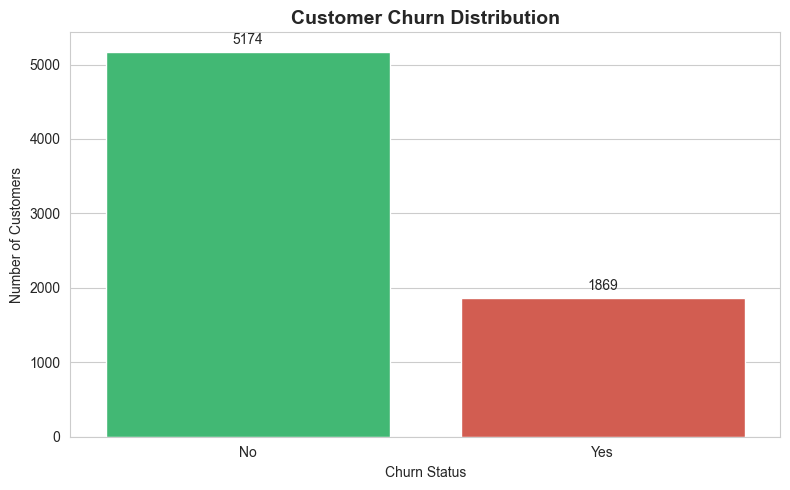

In [51]:
# Count the number of customers in each churn category
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)
print("\nChurn percentages:")
print(churn_percentages.round(2).astype(str) + "%")

# Create a bar plot for churn distribution
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#2ecc71", "#e74c3c"]  # Green for No, Red for Yes
sns.countplot(data=df, x="Churn", palette=colors, ax=ax)

ax.set_title("Customer Churn Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn Status")
ax.set_ylabel("Number of Customers")

# Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### Observation

- The dataset is moderately imbalanced, with **5,174 (73.46%)** customers remaining with the company and **1,869 (26.54%)** customers churning.
- Most customers have not churned, indicating that customer retention is higher than customer attrition.
- Since the target variable is not perfectly balanced, model evaluation should focus on metrics such as **Precision, Recall, F1-score, and ROC-AUC**, rather than relying solely on accuracy.
- This imbalance should be considered during model development to ensure the model effectively identifies customers who are likely to churn.

### Correlation Heatmap for Numerical Features

A correlation heatmap shows how strongly numerical features are related to each other. Values close to **+1** or **-1** indicate a strong positive or negative relationship, while values near **0** suggest little to no linear correlation.

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


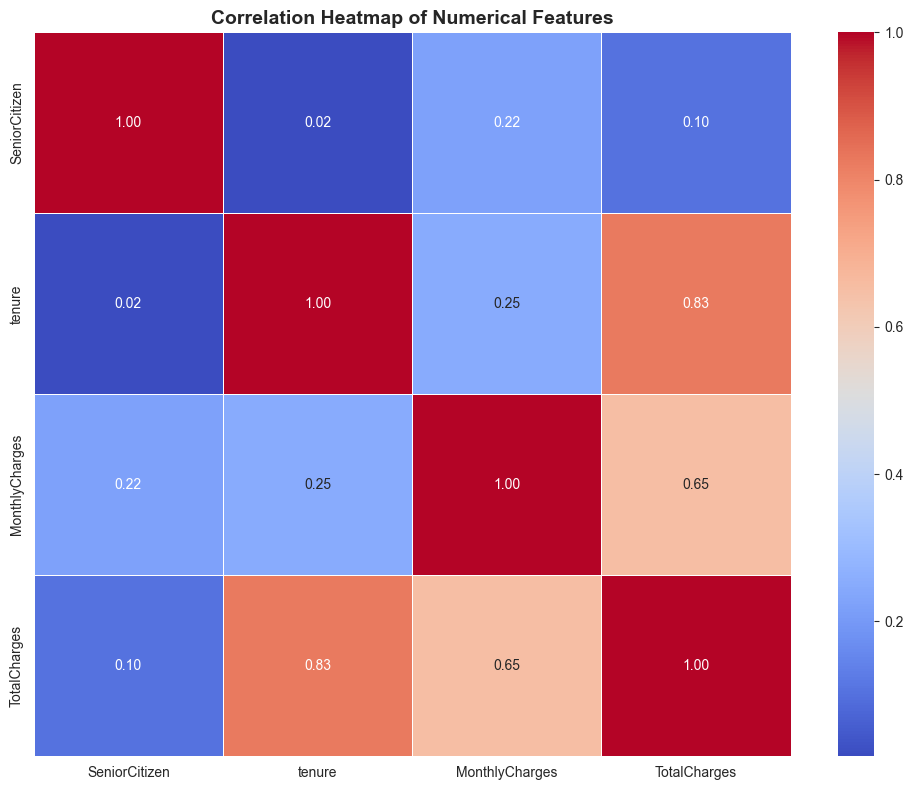

In [52]:
# Select only numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features: {numerical_cols}")

# Compute the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot the correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,       # Show correlation values on the heatmap
    fmt=".2f",        # Format numbers to 2 decimal places
    cmap="coolwarm",  # Color map: blue = negative, red = positive
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Observation

- The correlation heatmap indicates that **tenure** and **TotalCharges** have a strong positive correlation (**0.83**), suggesting that customers who stay longer generally accumulate higher total charges.
- **MonthlyCharges** has a moderate positive correlation with **TotalCharges** (**0.65**), as higher monthly billing contributes to larger total payments over time.
- **MonthlyCharges** and **tenure** show a weak positive correlation (**0.25**), indicating a limited linear relationship.
- **SeniorCitizen** exhibits very weak correlations with the other numerical features, suggesting that age alone has little linear association with these variables.
- Overall, no severe multicollinearity is observed except for the expected relationship between **tenure** and **TotalCharges**, which should be considered during feature selection and model building.

## Tenure Distribution

Customer tenure indicates how long customers have stayed with the company. Understanding its distribution helps identify whether most customers are new or long-term subscribers.


Histogram

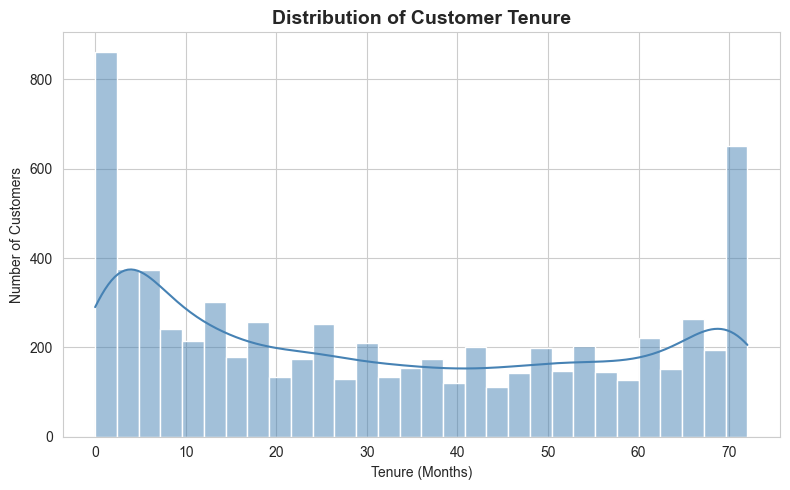

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True,
    color="steelblue",
    ax=ax
)

ax.set_title("Distribution of Customer Tenure", fontsize=14, fontweight="bold")
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Boxplot

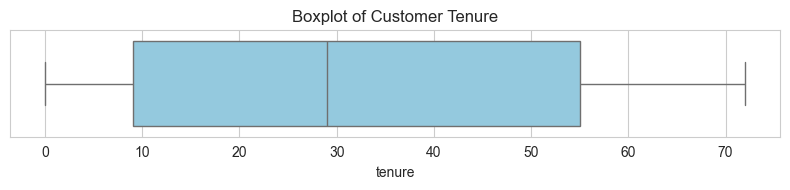

In [54]:
fig, ax = plt.subplots(figsize=(8, 2))

sns.boxplot(
    x=df["tenure"],
    color="skyblue",
    ax=ax
)

ax.set_title("Boxplot of Customer Tenure")

plt.tight_layout()
plt.show()

### Observation

- Customer tenure ranges from 0 to 72 months.
- Many customers have either recently joined or have stayed for a long period.
- No significant outliers are observed because tenure has a fixed range.
- Tenure may be an important feature for predicting customer churn.

## Monthly Charges Distribution

Monthly charges represent the amount billed to customers each month. Analyzing their distribution helps identify common pricing ranges and potential outliers.

Histogram

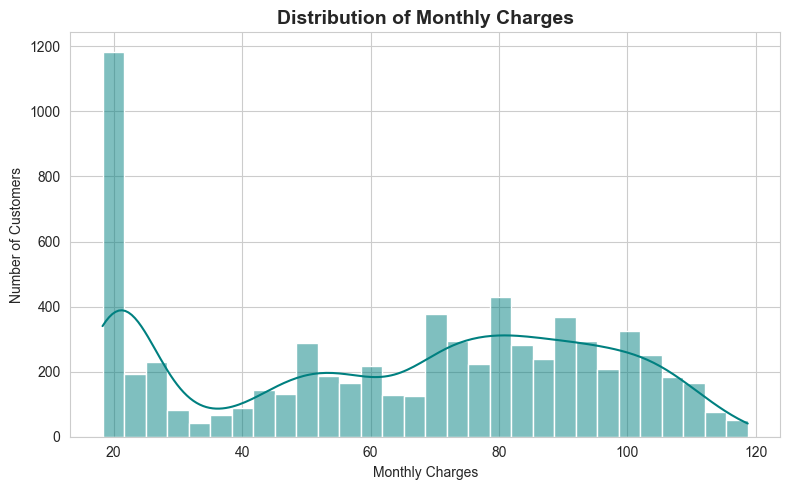

In [55]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True,
    color="teal",
    ax=ax
)

ax.set_title("Distribution of Monthly Charges", fontsize=14, fontweight="bold")
ax.set_xlabel("Monthly Charges")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Boxplot

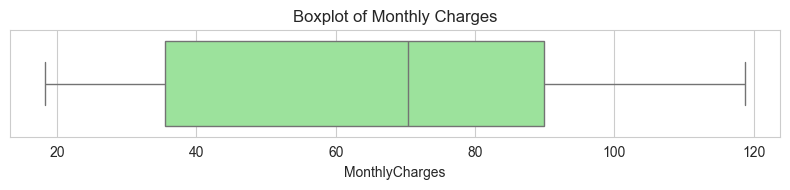

In [56]:
fig, ax = plt.subplots(figsize=(8, 2))

sns.boxplot(
    x=df["MonthlyCharges"],
    color="lightgreen",
    ax=ax
)

ax.set_title("Boxplot of Monthly Charges")

plt.tight_layout()
plt.show()

### Observation

- Monthly charges are distributed across a wide range of billing amounts.
- Most customers fall within the moderate monthly charge range, while fewer customers have extremely low or high charges.
- The distribution indicates that customers subscribe to different service plans with varying costs.
- Monthly charges are expected to be an important feature influencing customer churn.

## Total Charges Distribution

Total charges represent the cumulative amount paid by customers over their subscription period. This visualization helps understand spending patterns.

Histogram

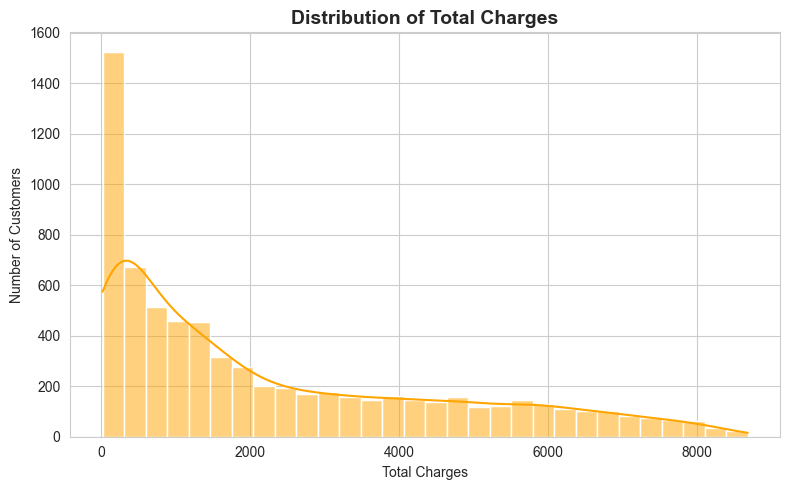

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=df,
    x="TotalCharges",
    bins=30,
    kde=True,
    color="orange",
    ax=ax
)

ax.set_title("Distribution of Total Charges", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Charges")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Boxplot

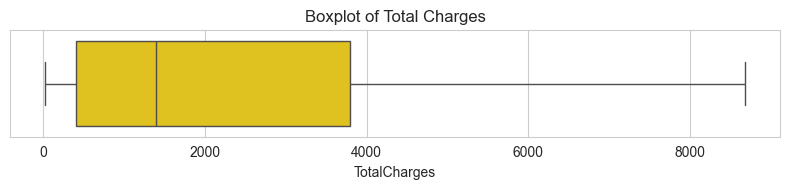

In [58]:
fig, ax = plt.subplots(figsize=(8, 2))

sns.boxplot(
    x=df["TotalCharges"],
    color="gold",
    ax=ax
)

ax.set_title("Boxplot of Total Charges")

plt.tight_layout()
plt.show()

### Observation

- Total charges exhibit a right-skewed distribution because long-term customers accumulate larger payments over time.
- Most customers have relatively lower total charges, while fewer customers have very high lifetime spending.
- The variation reflects differences in both customer tenure and monthly subscription costs.
- Total charges may provide valuable information for predicting customer retention.

## Churn by Gender

This analysis compares customer churn across different genders to determine whether gender influences churn behavior.

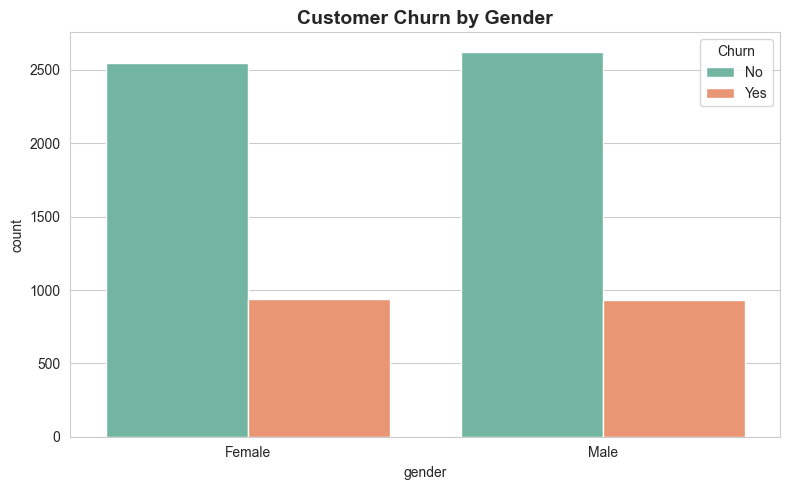

In [59]:
fig, ax = plt.subplots(figsize=(8,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn",
    palette="Set2",
    ax=ax
)

ax.set_title("Customer Churn by Gender", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- The distribution of churn is relatively similar between male and female customers.
- Both genders exhibit comparable retention and churn patterns, indicating that gender alone has a limited influence on customer churn.
- Any differences in churn between male and female customers are relatively small compared to other factors such as contract type, tenure, or monthly charges.
- Therefore, gender is likely to be a weaker predictor of customer churn than service-related features.

## Churn by Senior Citizen

Senior citizens may have different service requirements and usage patterns compared to younger customers. This analysis compares churn rates between senior and non-senior customers to determine whether age group influences customer retention.

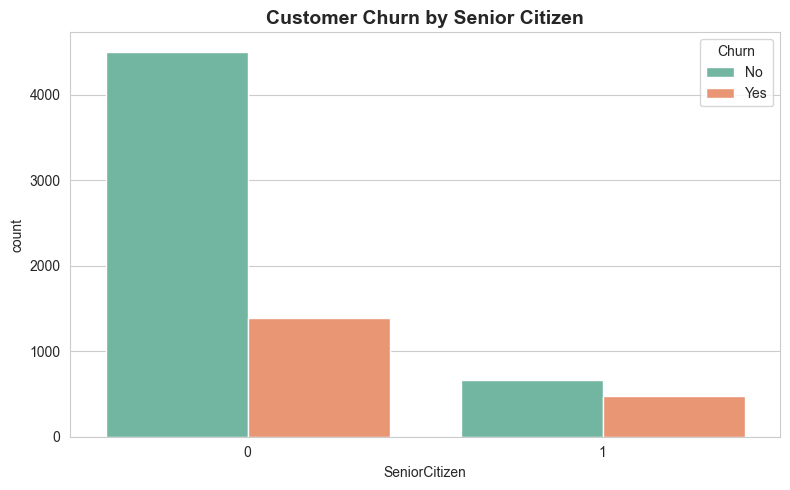

In [60]:
fig, ax = plt.subplots(figsize=(8,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn",
    palette="Set2",
    ax=ax
)

ax.set_title("Customer Churn by Senior Citizen", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

 ### Observation

- Senior citizens appear to have a higher proportion of churn compared to non-senior customers.
- Non-senior customers represent the majority of the dataset and generally show better retention.
- Age group may influence customer behavior and should be considered as a predictive feature.

## Churn by Contract Type

Customers may subscribe under different contract plans such as month-to-month, one-year, or two-year contracts. This visualization helps identify whether contract duration has an impact on customer churn.

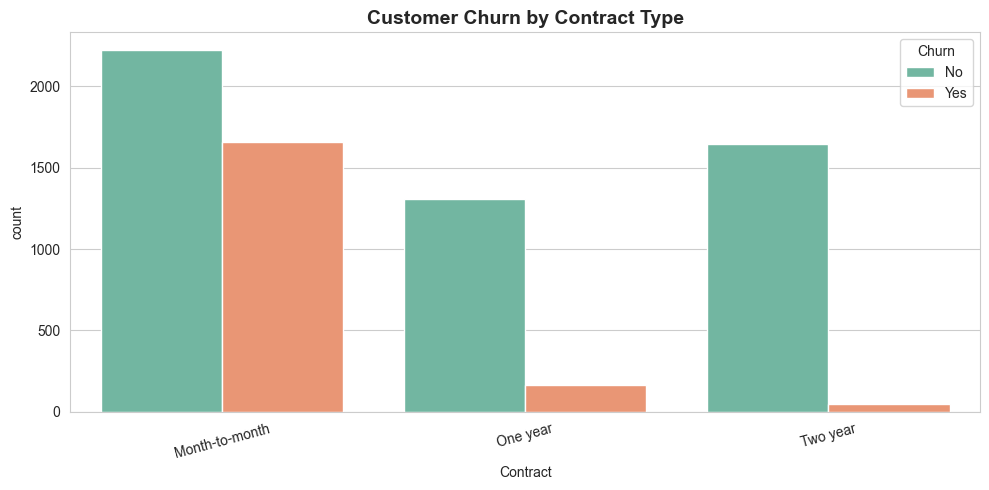

In [61]:
fig, ax = plt.subplots(figsize=(10,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set2",
    ax=ax
)

ax.set_title("Customer Churn by Contract Type", fontsize=14, fontweight="bold")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Observation

- Customers with **Month-to-month** contracts exhibit the highest churn rate.
- Customers with **One-year** and **Two-year** contracts are significantly more likely to remain with the company.
- Longer contract commitments appear to improve customer retention.
- Contract type is one of the strongest indicators of customer churn.

## Churn by Internet Service

Customers use different internet service types, including DSL, Fiber Optic, and customers without internet service. This analysis explores whether the type of internet service affects churn behavior.

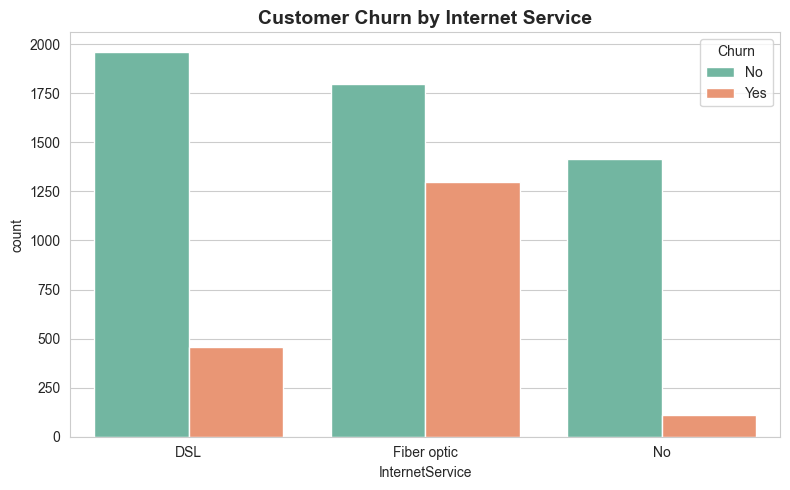

In [62]:
fig, ax = plt.subplots(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="Set2",
    ax=ax
)

ax.set_title("Customer Churn by Internet Service", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- Customers using **Fiber Optic** service show the highest churn compared to other internet service types.
- DSL customers generally demonstrate better retention.
- Customers without internet service have relatively low churn.
- Internet service type may significantly influence customer satisfaction and churn behavior.

## Churn by Payment Method

Customers can choose from multiple payment methods such as electronic check, mailed check, bank transfer, and credit card. This visualization examines whether certain payment methods are associated with higher customer churn.

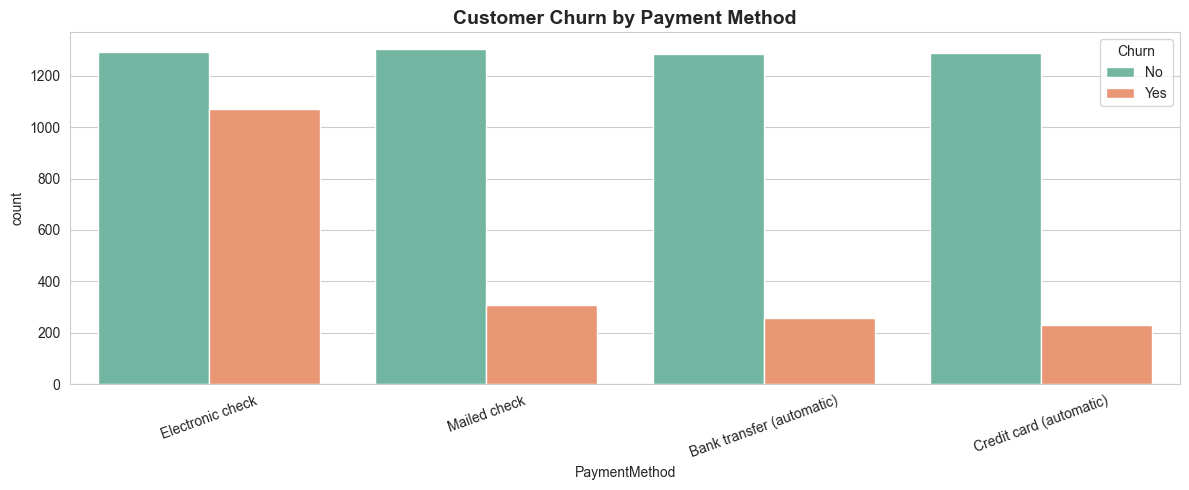

In [63]:
fig, ax = plt.subplots(figsize=(12,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="Set2",
    ax=ax
)

ax.set_title("Customer Churn by Payment Method", fontsize=14, fontweight="bold")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Observation

- Customers paying through **Electronic Check** exhibit noticeably higher churn than customers using other payment methods.
- Customers using automatic payment methods, such as bank transfer or credit card, tend to remain with the company.
- Payment method appears to influence customer retention and may serve as an important predictive feature.

## Monthly Charges vs Churn

Monthly charges are an important financial factor that may influence customer decisions. This boxplot compares the monthly billing amounts of customers who churned and those who remained with the company.

/var/folders/7h/kf46pm4131s_zw02f99gknx40000gn/T/ipykernel_15955/2422419041.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


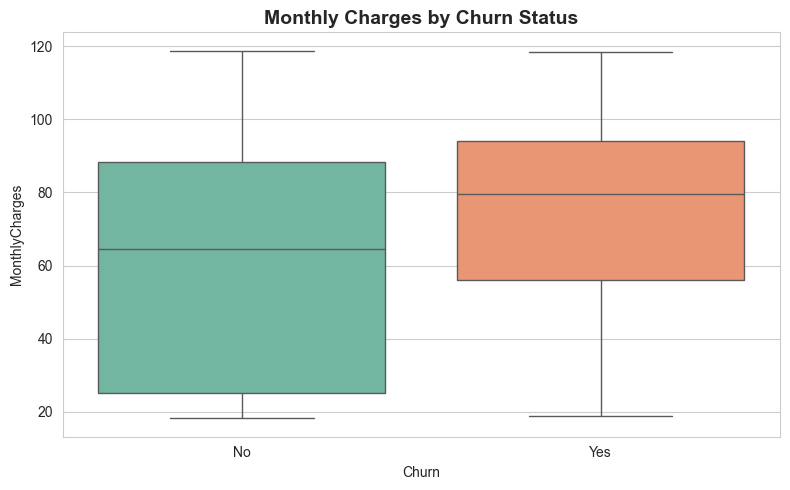

In [64]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Set2",
    ax=ax
)

ax.set_title("Monthly Charges by Churn Status", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- Customers who churn generally have higher monthly charges than customers who stay.
- The median monthly charge for churned customers is noticeably greater.
- This suggests that higher service costs may contribute to customer dissatisfaction and increased churn.
- Monthly charges appear to be a strong predictor of customer churn.

## Tenure vs Churn

Customer tenure represents the length of time a customer has stayed with the company. Comparing tenure across churn categories helps determine whether newer or long-term customers are more likely to leave.

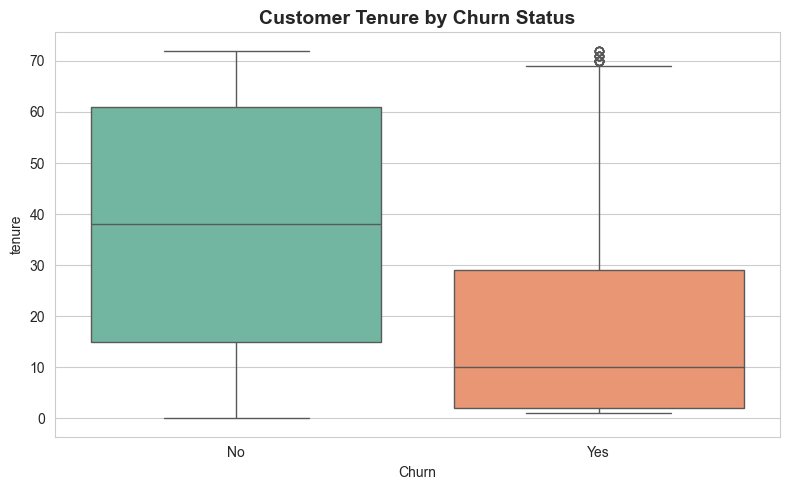

In [65]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    hue="Churn",
    palette="Set2",
    legend=False,
    ax=ax
)

ax.set_title("Customer Tenure by Churn Status", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- Customers who churn generally have much lower tenure than customers who remain with the company.
- The median tenure of churned customers is significantly lower, indicating that many customers leave within the early months of service.
- Customers who stay tend to have much longer subscription periods and a wider tenure distribution.
- Although a few long-term customers also churn, they represent a small portion of the dataset.
- Tenure is one of the strongest indicators of customer churn and is expected to contribute significantly to the machine learning model.

## Data Preprocessing

### Feature and Target Separation

Before training machine learning models, the dataset is divided into input features and the target variable. The target variable is Churn, while all remaining relevant columns are used as predictors.

In [66]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 20)
Target shape: (7043,)


### Target Variable Encoding

Machine learning algorithms require numerical target values. The Churn column is converted into binary format where Yes represents churned customers and No represents retained customers.

In [67]:
y = y.map({"No": 0, "Yes": 1})

print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


### Handling Missing Values

Missing values can negatively affect model performance. The missing values in TotalCharges are replaced using the median value of the column.

In [68]:
X["TotalCharges"] = X["TotalCharges"].fillna(X["TotalCharges"].median())

print(X.isnull().sum().sum())

0


### Feature Selection

Customer identifiers do not contribute to churn prediction and are removed from the dataset before model training.

In [69]:
print("Dataset shape:", X.shape)

print("\nRemaining columns:")
print(X.columns.tolist())

Dataset shape: (7043, 20)

Remaining columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


### Categorical Feature Encoding

Categorical variables are transformed into numerical representations using One-Hot Encoding so that machine learning algorithms can process them effectively.

In [70]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
X.head()

(7043, 7072)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


### Observation

- Missing values were successfully handled.
- Customer identifiers were removed as they do not contribute to prediction.
- All categorical variables were converted into numerical format.
- The dataset was split into training and testing sets using an 80:20 ratio.
- Numerical features were standardized to improve model performance.
- The processed dataset is now ready for machine learning model training.

# Model Building

Before training machine learning models, the dataset is divided into training and testing sets. The training set is used to learn patterns from the data, while the testing set is reserved for evaluating how well the trained models generalize to unseen customers.

An 80:20 split is used, and stratification ensures that the churn class distribution remains consistent in both sets.

## Train-Test Split

In [71]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 7072)
Testing Features  : (1409, 7072)
Training Labels   : (5634,)
Testing Labels    : (1409,)


### Observation

- The dataset has been successfully divided into training (80%) and testing (20%) sets.
- Stratified sampling preserves the original churn distribution in both subsets.
- The training data will be used for model learning, while the testing data will be used only for performance evaluation.

## Feature Scaling

Machine learning algorithms such as Logistic Regression and K-Nearest Neighbors are sensitive to feature scales. All input features were standardized using StandardScaler. The scaler was fitted on the training set and applied to the testing set to prevent data leakage.

The scaler is fitted only on the training data to prevent data leakage.

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


### Observation

- Numerical features have been standardized using StandardScaler.
- The scaler was fitted only on the training set and then applied to the testing set, preventing information leakage.
- Scaling ensures that distance-based and linear models perform more effectively.

## Logistic Regression

Logistic Regression is a linear classification algorithm widely used for binary classification problems. It estimates the probability of customer churn using a logistic function and serves as a strong baseline model.

In [73]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/Users/ashishpradhan0406/Documents/customer churn prediction/customer-churn-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ashishpradhan0406/Documents/customer churn prediction/customer-churn-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ashishpradhan0406/Documents/customer churn prediction/customer-churn-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ashishpradhan0406/Documents/customer churn prediction/customer-churn-prediction/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weight

### Observation

- Logistic Regression successfully learned the relationship between customer features and churn.
- This model will serve as the baseline for comparison with other machine learning algorithms.

## Decision Tree Classifier

Decision Trees classify customers by recursively splitting the dataset into smaller groups based on feature values. They are easy to interpret and can capture non-linear relationships.

In [74]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### Observation

- The Decision Tree model has been successfully trained.
- It can capture complex decision boundaries without requiring feature scaling.

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Observation

- The Random Forest model has been successfully trained.
- Combining multiple decision trees generally improves robustness and predictive performance.

## K-Nearest Neighbors (KNN)

KNN classifies customers based on the majority class of their nearest neighbors. Since it relies on distance calculations, standardized features are essential.

In [76]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

print("KNN model trained successfully.")

KNN model trained successfully.


### Observation

- The KNN model has been successfully trained using standardized features.
- It predicts churn based on the similarity between customers in the feature space.

## Summary

Four machine learning algorithms have been successfully trained:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors

The next phase focuses on evaluating these models using performance metrics such as Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix to identify the best-performing classifier for customer churn prediction.

# Model Evaluation

After training the machine learning models, their performance is evaluated using several classification metrics. These metrics provide insights into how accurately each model predicts customer churn and help identify the most suitable model for the problem.

The following evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

## Import Evaluation Libraries

The required evaluation metrics and visualization libraries are imported to assess and compare the performance of each machine learning model.

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

## Generate Predictions

Predictions are generated for each trained machine learning model using the testing dataset. These predictions are then used to calculate the evaluation metrics.

In [78]:
# Logistic Regression
lr_pred = log_model.predict(X_test_scaled)

# Decision Tree
dt_pred = dt_model.predict(X_test)

# Random Forest
rf_pred = rf_model.predict(X_test)

# KNN
knn_pred = knn_model.predict(X_test_scaled)

print("Predictions generated successfully.")

/Users/ashishpradhan0406/Documents/customer churn prediction/customer-churn-prediction/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ashishpradhan0406/Documents/customer churn prediction/customer-churn-prediction/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ashishpradhan0406/Documents/customer churn prediction/customer-churn-prediction/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Predictions generated successfully.


## Model Evaluation Function

A reusable evaluation function is created to calculate and display multiple performance metrics for each machine learning model.

In [79]:
results = []
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


## Logistic Regression Performance

The performance of the Logistic Regression model is evaluated using the testing dataset. Key classification metrics such as Accuracy, Precision, Recall, and F1-Score are calculated to measure the model's ability to correctly identify customers who are likely to churn.

In [80]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

Logistic Regression
Accuracy : 0.7842
Precision: 0.7215
Recall   : 0.3048
F1 Score : 0.4286


## Decision Tree Performance

The Decision Tree model is evaluated on the testing dataset to assess its predictive performance. The evaluation metrics help determine how effectively the model classifies churned and non-churned customers.

In [81]:
evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

Decision Tree
Accuracy : 0.7722
Precision: 0.5826
Recall   : 0.5000
F1 Score : 0.5381


## Random Forest Performance

The Random Forest model is evaluated using the testing dataset. As an ensemble learning algorithm, it combines predictions from multiple decision trees to improve classification performance and reduce overfitting.

In [82]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

Random Forest
Accuracy : 0.8006
Precision: 0.6755
Recall   : 0.4786
F1 Score : 0.5603


## K-Nearest Neighbors (KNN) Performance

The K-Nearest Neighbors model is evaluated using standardized testing data. The evaluation measures how accurately the model classifies customers based on the similarity of their features to neighboring data points.

In [83]:
evaluate_model(
    "K-Nearest Neighbors",
    y_test,
    knn_pred
)

K-Nearest Neighbors
Accuracy : 0.7608
Precision: 0.5737
Recall   : 0.3850
F1 Score : 0.4608


## Model Comparison Table

The evaluation metrics of all machine learning models are compiled into a comparison table to facilitate performance analysis and identify the best-performing model.

In [84]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.8006,0.6755,0.4786,0.5603
1,Decision Tree,0.7722,0.5826,0.5000,0.5381
3,K-Nearest Neighbors,0.7608,0.5737,0.3850,0.4608
0,Logistic Regression,0.7842,0.7215,0.3048,0.4286


### Observation

- Performance metrics were successfully calculated for all four machine learning models.
- Random Forest achieved the highest Accuracy (80.06%) and F1-Score (56.03%), indicating the best overall predictive performance.
- Logistic Regression achieved the highest Precision (72.15%), meaning it produced the fewest false positive churn predictions.
- Decision Tree obtained the highest Recall (50.00%), making it slightly better at identifying actual churned customers.
- K-Nearest Neighbors showed comparatively lower performance across most evaluation metrics.
- Since customer churn prediction is an imbalanced classification problem, F1-Score provides a more reliable measure than Accuracy alone.
- Based on these evaluation metrics, Random Forest is selected as the best-performing model for customer churn prediction.

# Save the Best Model

The best-performing machine learning model is saved using the Joblib library. Saving the trained model allows it to be reused for future predictions without retraining.

In [87]:
import joblib

joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [88]:
import os

print(os.listdir("../models"))

['random_forest_model.pkl']


In [89]:
loaded_model = joblib.load("../models/random_forest_model.pkl")

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


### Observation

- The best-performing Random Forest model was successfully saved using the Joblib library.
- Saving the trained model enables future predictions without retraining, improving efficiency and supporting deployment in real-world applications.